In [9]:
#!/usr/bin/env python3
"""
Baseline Index Evaluation Notebook

This notebook evaluates the baseline TF-IDF index created with quick_builder.py
It performs sanity checks and comprehensive evaluation using the texto-resumen
document pairs with proper memory management.
"""

import gc
import sys
import pickle
import random
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Dict, Any, Tuple, Optional
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import psutil
import torch

# Add project root to path
project_root = Path('/work')
sys.path.append(str(project_root))

# Import our modules
from src.utils.evaluation import (
    perform_single_match_analysis, 
    print_single_match_analysis,
    perform_prefix_match_analysis,
    print_prefix_match_analysis,
    print_sample_results
)
from sandbox.splade.indexing.quick_builder import (
    QuickSearchIndex, 
    QuickVectorizer, 
    load_baseline_index,
    load_documents_from_pickle
)
from sandbox.splade.core.vocabulary import VocabularyBuilder

class MemoryManager:
    """Utility class for monitoring and managing memory usage."""
    
    def __init__(self, verbose: bool = True):
        self.verbose = verbose
        self.initial_memory = self.get_memory_usage()
    
    def get_memory_usage(self) -> Dict[str, float]:
        """Get current memory usage in GB."""
        process = psutil.Process()
        memory_info = process.memory_info()
        
        return {
            'rss': memory_info.rss / (1024**3),  # GB
            'vms': memory_info.vms / (1024**3),  # GB
            'percent': process.memory_percent()
        }
    
    def print_memory_status(self, label: str = ""):
        """Print current memory status."""
        if not self.verbose:
            return
            
        current = self.get_memory_usage()
        print(f"💾 Memory Status {label}:")
        print(f"   RSS: {current['rss']:.2f} GB")
        print(f"   VMS: {current['vms']:.2f} GB") 
        print(f"   Percent: {current['percent']:.1f}%")
    
    def cleanup(self):
        """Force garbage collection and cleanup."""
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    def memory_cleanup_decorator(self, func):
        """Decorator to automatically cleanup memory after function execution."""
        def wrapper(*args, **kwargs):
            try:
                result = func(*args, **kwargs)
                return result
            finally:
                self.cleanup()
        return wrapper


class BaselineIndexEvaluator:
    """Comprehensive evaluator for baseline TF-IDF indices."""
    
    def __init__(self, 
                 index_path: str,
                 vocab_path: str,
                 data_path: str,
                 file_base: str = "OEB",
                 use_filtered_vocab: bool = True,
                 max_features: Optional[int] = 10000):
        """
        Initialize evaluator.
        
        Args:
            index_path: Path to saved baseline index
            vocab_path: Path to vocabulary directory
            data_path: Path to data directory  
            file_base: Base filename
            use_filtered_vocab: Whether using filtered vocabulary
            max_features: Maximum vocabulary features used
        """
        self.index_path = Path(index_path)
        self.vocab_path = Path(vocab_path)
        self.data_path = Path(data_path)
        self.file_base = file_base
        self.use_filtered_vocab = use_filtered_vocab
        self.max_features = max_features
        
        # Initialize memory manager
        self.memory_manager = MemoryManager(verbose=True)
        
        # Initialize components
        self.index = None
        self.resumen_docs = None
        self.texto_docs = None
        
        print(f"BaselineIndexEvaluator initialized:")
        print(f"  Index path: {index_path}")
        print(f"  File base: {file_base}")
        print(f"  Using filtered vocab: {use_filtered_vocab}")
        print(f"  Max features: {max_features}")
    
    def load_or_build_index(self, force_rebuild: bool = False):
        """Load existing index or build it if it doesn't exist."""
        print("📁 Loading or building baseline index...")
        self.memory_manager.print_memory_status("before index loading")
        
        try:
            # Load vocabulary first
            vocab_suffix = "filtered" if self.use_filtered_vocab else "full"
            vocab_full_path = self.vocab_path / f"{self.file_base}_vocab_{vocab_suffix}_50000"
            
            print(f"Loading vocabulary from: {vocab_full_path}")
            vocab_builder = VocabularyBuilder.load_vocabulary(vocab_full_path)
            
            # Determine index path
            vocab_type = "filtered" if self.use_filtered_vocab else "full"
            features_suffix = f"_{self.max_features}" if self.max_features else ""
            index_name = f"{self.file_base}_baseline_index_{vocab_type}{features_suffix}"
            
            full_index_path = self.index_path / index_name
            
            # Check if index exists and load it
            if full_index_path.exists() and not force_rebuild:
                print(f"Loading existing index from: {full_index_path}")
                self.index = QuickSearchIndex.load(full_index_path, vocab_builder)
                
                # Print index statistics
                stats = self.index.get_index_statistics()
                print(f"✅ Index loaded successfully:")
                print(f"   Documents: {stats['total_documents']:,}")
                print(f"   Vocabulary size: {stats['vocabulary_size']:,}")
                print(f"   Sparsity: {stats['sparsity']:.3f}")
                
            else:
                # Build index from scratch
                if force_rebuild:
                    print(f"🔨 Force rebuilding index...")
                else:
                    print(f"🔨 Index not found. Building new index...")
                
                self.index = self._build_new_index(vocab_builder, full_index_path)
                
                # Print index statistics
                stats = self.index.get_index_statistics()
                print(f"✅ Index built and saved successfully:")
                print(f"   Documents: {stats['total_documents']:,}")
                print(f"   Vocabulary size: {stats['vocabulary_size']:,}")
                print(f"   Sparsity: {stats['sparsity']:.3f}")
            
            self.memory_manager.print_memory_status("after index loading/building")
            
        except Exception as e:
            print(f"❌ Failed to load/build index: {e}")
            raise
    
    def _build_new_index(self, vocab_builder: VocabularyBuilder, save_path: Path) -> QuickSearchIndex:
        """Build a new baseline index."""
        from sandbox.splade.indexing.quick_builder import QuickVectorizer, QuickSearchIndex
        
        print(f"🔧 Building new baseline index...")
        print(f"   Vocabulary: {'filtered' if self.use_filtered_vocab else 'full'}")
        print(f"   Max features: {self.max_features}")
        
        # Create vectorizer
        vectorizer = QuickVectorizer(vocab_builder, max_features=self.max_features)
        
        # Load texto documents
        print(f"📄 Loading texto documents for indexing...")
        texto_path = self.data_path / f"{self.file_base}_texto.pkl"
        
        if not texto_path.exists():
            raise FileNotFoundError(f"Texto documents not found at: {texto_path}")
        
        with open(texto_path, 'rb') as f:
            texto_docs = pickle.load(f)
        
        print(f"   Loaded {len(texto_docs)} texto documents")
        
        # Create and build index
        index = QuickSearchIndex(vectorizer)
        print(f"🏗️  Building index (this may take a few minutes)...")
        
        index.index_documents(
            texto_docs, 
            text_field="text", 
            key_field="doc_id",
            batch_size=1000
        )
        
        # Save index
        print(f"💾 Saving index to: {save_path}")
        index.save(save_path)
        
        # Cleanup texto docs from memory
        del texto_docs
        self.memory_manager.cleanup()
        
        return index
    
    def load_index(self):
        """Legacy method for backwards compatibility."""
        self.load_or_build_index(force_rebuild=False)
    
    def load_documents(self, doc_type: str = "resumen"):
        """Load documents (resumen or texto)."""
        print(f"📄 Loading {doc_type} documents...")
        
        doc_path = self.data_path / f"{self.file_base}_{doc_type}.pkl"
        
        if not doc_path.exists():
            raise FileNotFoundError(f"Document file not found: {doc_path}")
        
        with open(doc_path, 'rb') as f:
            docs = pickle.load(f)
        
        print(f"✅ Loaded {len(docs)} {doc_type} documents")
        
        if doc_type == "resumen":
            self.resumen_docs = docs
        elif doc_type == "texto":
            self.texto_docs = docs
        
        return docs
    
    def sanity_check(self, num_checks: int = 5, top_k: int = 5) -> List[Dict[str, Any]]:
        """
        Perform sanity checks by searching for random texto documents.
        
        Args:
            num_checks: Number of random documents to test
            top_k: Number of top results to retrieve
            
        Returns:
            List of sanity check results
        """
        print(f"🧪 Performing sanity checks with {num_checks} random texto documents...")
        
        if self.index is None:
            raise ValueError("Index not loaded. Call load_index() first.")
        
        # Get random sample of texto documents for sanity check
        if self.texto_docs is None:
            self.load_documents("texto")
        
        # Sample random documents
        sample_docs = random.sample(self.texto_docs, min(num_checks, len(self.texto_docs)))
        
        sanity_results = []
        
        for i, doc in enumerate(sample_docs):
            print(f"\n📝 Sanity check {i+1}/{num_checks}")
            print("-" * 60)
            
            # Extract document info - try different ways to get the item_key
            doc_text = doc.text if hasattr(doc, 'text') else str(doc)
            
            # Try to get the correct item_key (the one used in the index)
            doc_key = None
            if hasattr(doc, 'metadata') and isinstance(doc.metadata, dict):
                # Look for item_key in metadata first
                if 'item_key' in doc.metadata:
                    doc_key = doc.metadata['item_key']
                elif 'doc_id' in doc.metadata:
                    doc_key = doc.metadata['doc_id']
            
            # Fallback to other attributes
            if doc_key is None:
                if hasattr(doc, 'item_key'):
                    doc_key = doc.item_key
                elif hasattr(doc, 'doc_id'):
                    doc_key = doc.doc_id
                else:
                    doc_key = f"unknown_doc_{i}"
            
            print(f"🎯 Target Document:")
            print(f"   Item Key: {doc_key}")
            print(f"   Text: {doc_text}")
            
            # Search with document text as query
            search_results = self.index.search(doc_text, top_k=top_k, min_score=0.0)
            
            print(f"\n🔍 Top {len(search_results)} Retrieved Results:")
            
            # Check if target document is in results
            target_found = False
            target_position = -1
            target_score = 0.0
            
            for pos, result in enumerate(search_results):
                is_target = result.item_key == doc_key
                marker = "🎯 TARGET" if is_target else "  "
                
                print(f"\n   {marker} Result {pos+1}:")
                print(f"      Item Key: {result.item_key}")
                print(f"      Score: {result.score:.6f}")
                print(f"      Text: {result.text}")
                
                if is_target:
                    target_found = True
                    target_position = pos + 1
                    target_score = result.score
            
            # Summary for this check
            if target_found:
                print(f"\n✅ Target found at position {target_position} with score {target_score:.6f}")
            else:
                print(f"\n❌ Target NOT found in top {top_k} results")
                print(f"   This may indicate an issue with item_key matching or index")
            
            # Prepare result
            sanity_result = {
                'doc_key': doc_key,
                'doc_text': doc_text,
                'target_found': target_found,
                'target_position': target_position,
                'target_score': target_score,
                'top_results': [
                    {
                        'item_key': result.item_key,
                        'text': result.text,
                        'score': result.score
                    }
                    for result in search_results
                ]
            }
            
            sanity_results.append(sanity_result)
        
        # Print overall sanity check summary
        print(f"\n" + "="*60)
        print(f"📋 SANITY CHECK SUMMARY")
        print(f"="*60)
        print(f"Checks performed: {len(sanity_results)}")
        
        found_at_1 = sum(1 for r in sanity_results if r['target_position'] == 1)
        found_in_top_k = sum(1 for r in sanity_results if r['target_found'])
        
        print(f"Found at position 1: {found_at_1}/{len(sanity_results)} ({found_at_1/len(sanity_results):.1%})")
        print(f"Found in top {top_k}: {found_in_top_k}/{len(sanity_results)} ({found_in_top_k/len(sanity_results):.1%})")
        
        if found_at_1 < len(sanity_results) * 0.8:
            print(f"⚠️  Warning: Low self-retrieval rate. Index may have issues.")
        else:
            print(f"✅ Good self-retrieval rate. Index appears healthy.")
        
        return sanity_results
    
    def evaluate_batch(self, 
                      resumen_batch: List[Any], 
                      batch_id: int,
                      top_k: int = 10) -> List[Dict[str, Any]]:
        """
        Evaluate a batch of resumen documents.
        
        Args:
            resumen_batch: Batch of resumen documents
            batch_id: Batch identifier
            top_k: Number of top results to retrieve
            
        Returns:
            List of evaluation results
        """
        batch_results = []
        
        for i, resumen_doc in enumerate(resumen_batch):
            # Extract query info - try different ways to get the item_key
            query_text = resumen_doc.text if hasattr(resumen_doc, 'text') else str(resumen_doc)
            
            # Try to get the correct item_key that matches what's in the index
            query_key = None
            if hasattr(resumen_doc, 'metadata') and isinstance(resumen_doc.metadata, dict):
                # Look for item_key in metadata first
                if 'item_key' in resumen_doc.metadata:
                    query_key = resumen_doc.metadata['item_key']
                elif 'doc_id' in resumen_doc.metadata:
                    query_key = resumen_doc.metadata['doc_id']
            
            # Fallback to other attributes
            if query_key is None:
                if hasattr(resumen_doc, 'item_key'):
                    query_key = resumen_doc.item_key
                elif hasattr(resumen_doc, 'doc_id'):
                    query_key = resumen_doc.doc_id
                else:
                    query_key = f"resumen_{batch_id}_{i}"
            
            # Search index
            search_results = self.index.search(query_text, top_k=top_k, min_score=0.0)
            
            # Find target document info
            target_text = ""
            target_score = 0.0
            
            # Look for matching texto document
            # Direct lookup by key + compute actual similarity
            target_doc_info = self.index.get_document_by_key(query_key)
            if target_doc_info:
                target_text = target_doc_info['text']  # Always found!
                target_score = self._compute_target_similarity(query_text, target_doc_info)
            
            # Prepare result in format expected by evaluation.py
            eval_result = {
                'resumen_item_key': query_key,
                'resumen_text': query_text,
                'target_text': target_text,
                'target_score': target_score,
                'texto_results': [
                    {
                        'item_key': result.item_key,
                        'text': result.text,
                        'score': result.score
                    }
                    for result in search_results
                ]
            }
            
            batch_results.append(eval_result)
        
        return batch_results

    def _compute_target_similarity(self, query_text: str, target_doc_info: Dict[str, Any]) -> float:
        """
        Compute similarity between query text and target document.
        
        Args:
            query_text: Query text (resumen)
            target_doc_info: Target document info from index
            
        Returns:
            Cosine similarity score
        """
        try:
            # Get query vector
            query_vector = self.index.vectorizer.transform_single(query_text)
            
            # Get target vector (already computed and stored)
            target_vector = target_doc_info['vector']
            
            # Compute cosine similarity
            from sklearn.metrics.pairwise import cosine_similarity
            similarity = cosine_similarity(query_vector, target_vector)[0, 0]
            
            return float(similarity)
            
        except Exception as e:
            print(f"⚠️  Warning: Could not compute target similarity: {e}")
            return 0.0

    def comprehensive_evaluation(self, 
                                sample_size: int = 1000,
                                batch_size: int = 100,
                                top_k: int = 10,
                                random_seed: int = 42) -> Dict[str, Any]:
        """
        Perform comprehensive evaluation on resumen documents.
        
        Args:
            sample_size: Number of resumen documents to evaluate
            batch_size: Batch size for processing
            top_k: Number of top results to retrieve
            random_seed: Random seed for reproducibility
            
        Returns:
            Comprehensive evaluation results
        """
        print(f"🔬 Starting comprehensive evaluation...")
        print(f"   Sample size: {sample_size:,}")
        print(f"   Batch size: {batch_size}")
        print(f"   Top K: {top_k}")
        
        if self.index is None:
            raise ValueError("Index not loaded. Call load_index() first.")
        
        # Load resumen documents if not already loaded
        if self.resumen_docs is None:
            self.load_documents("resumen")
        
        # Set random seed for reproducibility
        random.seed(random_seed)
        
        # Sample documents
        actual_sample_size = min(sample_size, len(self.resumen_docs))
        sample_docs = random.sample(self.resumen_docs, actual_sample_size)
        
        print(f"   Actual sample size: {actual_sample_size:,}")
        
        # Process in batches
        all_results = []
        num_batches = (actual_sample_size + batch_size - 1) // batch_size
        
        self.memory_manager.print_memory_status("before evaluation")
        
        for batch_id in tqdm(range(num_batches), desc="Processing batches"):
            # Get batch
            start_idx = batch_id * batch_size
            end_idx = min(start_idx + batch_size, actual_sample_size)
            batch_docs = sample_docs[start_idx:end_idx]
            
            # Process batch
            batch_results = self.evaluate_batch(batch_docs, batch_id, top_k)
            all_results.extend(batch_results)
            
            # Memory cleanup after each batch
            self.memory_manager.cleanup()
            
            # Print progress every 10 batches
            if (batch_id + 1) % 10 == 0:
                self.memory_manager.print_memory_status(f"after batch {batch_id + 1}")
        
        print(f"✅ Evaluation complete. Processed {len(all_results)} queries.")
        
        # Calculate metrics
        print(f"📊 Calculating evaluation metrics...")
        
        # Single match analysis (exact key matching)
        single_match_metrics = perform_single_match_analysis(all_results, top_k)
        
        # Prefix match analysis (first 6 characters)
        prefix_match_metrics = perform_prefix_match_analysis(all_results, top_k, prefix_length=6)
        
        # Combine results
        evaluation_results = {
            'sample_size': len(all_results),
            'top_k': top_k,
            'batch_size': batch_size,
            'single_match_metrics': single_match_metrics,
            'prefix_match_metrics': prefix_match_metrics,
            'all_results': all_results,
            'index_stats': self.index.get_index_statistics(),
        }
        
        self.memory_manager.print_memory_status("after evaluation")
        
        return evaluation_results
    
    def print_evaluation_summary(self, evaluation_results: Dict[str, Any]):
        """Print comprehensive evaluation summary."""
        print("\n" + "="*80)
        print("BASELINE INDEX EVALUATION SUMMARY")
        print("="*80)
        
        print(f"Sample size: {evaluation_results['sample_size']:,}")
        print(f"Top K: {evaluation_results['top_k']}")
        
        # Index statistics
        stats = evaluation_results['index_stats']
        print(f"\nIndex Statistics:")
        print(f"  Documents: {stats['total_documents']:,}")
        print(f"  Vocabulary size: {stats['vocabulary_size']:,}")
        print(f"  Sparsity: {stats['sparsity']:.3f}")
        print(f"  Avg doc length: {stats['avg_doc_length']:.1f} chars")
        
        # Single match metrics
        print_single_match_analysis(evaluation_results['single_match_metrics'], evaluation_results['top_k'])
        
        # Prefix match metrics
        print_prefix_match_analysis(evaluation_results['prefix_match_metrics'], evaluation_results['top_k'], prefix_length=6)
    
    def visualize_results(self, evaluation_results: Dict[str, Any], save_path: Optional[str] = None):
        """Create visualizations for evaluation results."""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Position distribution (single match)
        single_metrics = evaluation_results['single_match_metrics']
        positions = list(range(1, evaluation_results['top_k'] + 1))
        single_freqs = [single_metrics['Position_Distribution'][f'Position_{p}'] for p in positions]
        
        axes[0, 0].bar(positions, single_freqs, alpha=0.7, color='skyblue')
        axes[0, 0].set_title('Single Match: Position Distribution')
        axes[0, 0].set_xlabel('Position')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].grid(True, alpha=0.3)
        
        # Position distribution (prefix match)
        prefix_metrics = evaluation_results['prefix_match_metrics']
        prefix_freqs = [prefix_metrics['Prefix_Position_Distribution'][f'Prefix_Position_{p}'] for p in positions]
        
        axes[0, 1].bar(positions, prefix_freqs, alpha=0.7, color='lightcoral')
        axes[0, 1].set_title('Prefix Match: Position Distribution')
        axes[0, 1].set_xlabel('Position')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].grid(True, alpha=0.3)
        
        # Comparison of key metrics
        metrics_names = ['Success@K', 'MRR', 'Perfect Matches']
        single_values = [
            single_metrics['Success@K'],
            single_metrics['MRR'],
            single_metrics['Perfect Matches']
        ]
        prefix_values = [
            prefix_metrics['Prefix_Success@K'],
            prefix_metrics['Prefix_MRR'],
            prefix_metrics['Prefix_Perfect_Matches']
        ]
        
        x = np.arange(len(metrics_names))
        width = 0.35
        
        axes[1, 0].bar(x - width/2, single_values, width, label='Single Match', alpha=0.7, color='skyblue')
        axes[1, 0].bar(x + width/2, prefix_values, width, label='Prefix Match', alpha=0.7, color='lightcoral')
        axes[1, 0].set_title('Metrics Comparison')
        axes[1, 0].set_ylabel('Score')
        axes[1, 0].set_xticks(x)
        axes[1, 0].set_xticklabels(metrics_names)
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # Score distribution
        all_results = evaluation_results['all_results']
        scores = []
        for result in all_results:
            if result['texto_results']:
                scores.append(result['texto_results'][0]['score'])  # Top score
        
        axes[1, 1].hist(scores, bins=50, alpha=0.7, color='green', edgecolor='black')
        axes[1, 1].set_title('Top Score Distribution')
        axes[1, 1].set_xlabel('Cosine Similarity Score')
        axes[1, 1].set_ylabel('Frequency')
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"📊 Visualizations saved to: {save_path}")
        
        plt.show()
    
    def save_results(self, 
                    evaluation_results: Dict[str, Any], 
                    save_path: str,
                    include_detailed_results: bool = False):
        """Save evaluation results to file."""
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        
        # Prepare data to save
        save_data = {
            'config': {
                'file_base': self.file_base,
                'use_filtered_vocab': self.use_filtered_vocab,
                'max_features': self.max_features,
                'sample_size': evaluation_results['sample_size'],
                'top_k': evaluation_results['top_k'],
                'batch_size': evaluation_results['batch_size'],
            },
            'index_stats': evaluation_results['index_stats'],
            'single_match_metrics': evaluation_results['single_match_metrics'],
            'prefix_match_metrics': evaluation_results['prefix_match_metrics'],
        }
        
        # Include detailed results if requested
        if include_detailed_results:
            save_data['detailed_results'] = evaluation_results['all_results']
        
        # Save as pickle for full data preservation
        with open(save_path, 'wb') as f:
            pickle.dump(save_data, f)
        
        print(f"💾 Evaluation results saved to: {save_path}")
        
        # Also save summary as JSON for easy reading
        json_path = save_path.with_suffix('.json')
        import json
        
        # Create JSON-serializable version
        json_data = {
            'config': save_data['config'],
            'summary_metrics': {
                'single_match': {
                    'success_at_k': evaluation_results['single_match_metrics']['Success@K'],
                    'mrr': evaluation_results['single_match_metrics']['MRR'],
                    'perfect_matches': evaluation_results['single_match_metrics']['Perfect Matches'],
                },
                'prefix_match': {
                    'success_at_k': evaluation_results['prefix_match_metrics']['Prefix_Success@K'],
                    'mrr': evaluation_results['prefix_match_metrics']['Prefix_MRR'],
                    'perfect_matches': evaluation_results['prefix_match_metrics']['Prefix_Perfect_Matches'],
                }
            },
            'index_stats': evaluation_results['index_stats']
        }
        
        with open(json_path, 'w') as f:
            json.dump(json_data, f, indent=2, ensure_ascii=False)
        
        print(f"📄 Summary saved to: {json_path}")


def run_baseline_evaluation(file_base: str = "OEB",
                          use_filtered_vocab: bool = True,
                          max_features: int = 10000,
                          sample_size: int = 1000,
                          batch_size: int = 100,
                          top_k: int = 10,
                          save_results: bool = True,
                          show_visualizations: bool = True) -> Dict[str, Any]:
    """
    Run complete baseline evaluation workflow.
    
    Args:
        file_base: Base filename
        use_filtered_vocab: Whether to use filtered vocabulary
        max_features: Maximum vocabulary features
        sample_size: Number of documents to evaluate
        batch_size: Batch size for processing
        top_k: Number of top results to retrieve
        save_results: Whether to save results
        show_visualizations: Whether to show plots
        
    Returns:
        Evaluation results
    """
    print("🚀 Starting Baseline Index Evaluation")
    print("="*50)
    
    # Initialize evaluator
    evaluator = BaselineIndexEvaluator(
        index_path="/work/sandbox/splade/baseline_indices",
        vocab_path="/work/sandbox/splade/vocabularies",
        data_path="/work/data/processed",
        file_base=file_base,
        use_filtered_vocab=use_filtered_vocab,
        max_features=max_features
    )
    
    try:
        # Load or build index
        evaluator.load_or_build_index()
        
        # Perform sanity checks
        print("\n" + "="*50)
        print("SANITY CHECKS")
        print("="*50)
        sanity_results = evaluator.sanity_check(num_checks=5, top_k=5)
        
        # Show sample sanity check
        if sanity_results:
            print(f"\n📋 Sample Sanity Check Result:")
            sample = sanity_results[0]
            print(f"   Target Key: {sample['doc_key']}")
            print(f"   Found: {sample['target_found']}")
            print(f"   Position: {sample['target_position']}")
            print(f"   Score: {sample['target_score']:.4f}")
        
        # Comprehensive evaluation
        print("\n" + "="*50)
        print("COMPREHENSIVE EVALUATION")
        print("="*50)
        evaluation_results = evaluator.comprehensive_evaluation(
            sample_size=sample_size,
            batch_size=batch_size,
            top_k=top_k
        )
        
        # Print summary
        evaluator.print_evaluation_summary(evaluation_results)
        
        # Show sample results
        print("\n" + "="*50)
        print("SAMPLE RESULTS")
        print("="*50)
        print_sample_results(evaluation_results['all_results'], num_samples=3, top_k=5)
        
        # Visualizations
        if show_visualizations:
            print("\n📊 Creating visualizations...")
            evaluator.visualize_results(evaluation_results)
        
        # Save results
        if save_results:
            vocab_type = "filtered" if use_filtered_vocab else "full"
            results_path = f"/work/sandbox/splade/evaluation_results/{file_base}_baseline_eval_{vocab_type}_{max_features}_{sample_size}.pkl"
            evaluator.save_results(evaluation_results, results_path, include_detailed_results=True)
        
        print(f"\n✅ Baseline evaluation complete!")
        
        # Add sanity results to final results
        evaluation_results['sanity_checks'] = sanity_results
        
        return evaluation_results
        
    except Exception as e:
        print(f"❌ Evaluation failed: {e}")
        import traceback
        traceback.print_exc()
        raise
    
    finally:
        # Final cleanup
        evaluator.memory_manager.cleanup()
        evaluator.memory_manager.print_memory_status("final cleanup")


# Quick functions for building index if needed
def build_baseline_index(file_base: str = "OEB",
                        use_filtered_vocab: bool = True,
                        max_features: int = 10000,
                        force_rebuild: bool = False) -> QuickSearchIndex:
    """Build baseline index if it doesn't exist."""
    print("🔨 Building baseline index...")
    
    evaluator = BaselineIndexEvaluator(
        index_path="/work/sandbox/splade/baseline_indices",
        vocab_path="/work/sandbox/splade/vocabularies", 
        data_path="/work/data/processed",
        file_base=file_base,
        use_filtered_vocab=use_filtered_vocab,
        max_features=max_features
    )
    
    evaluator.load_or_build_index(force_rebuild=force_rebuild)
    return evaluator.index


def check_index_exists(file_base: str = "OEB",
                      use_filtered_vocab: bool = True,
                      max_features: int = 10000) -> bool:
    """Check if baseline index exists."""
    vocab_type = "filtered" if use_filtered_vocab else "full"
    features_suffix = f"_{max_features}" if max_features else ""
    index_name = f"{file_base}_baseline_index_{vocab_type}{features_suffix}"
    
    index_path = Path("/work/sandbox/splade/baseline_indices") / index_name
    exists = index_path.exists()
    
    print(f"Index {'exists' if exists else 'does not exist'} at: {index_path}")
    return exists


# Quick evaluation functions for Jupyter notebook usage
def quick_evaluation(sample_size: int = 500, 
                    max_features: int = 5000) -> Dict[str, Any]:
    """Quick evaluation with smaller parameters for testing."""
    return run_baseline_evaluation(
        sample_size=sample_size,
        max_features=max_features,
        batch_size=50,
        top_k=10,
        save_results=True,
        show_visualizations=True
    )


def full_evaluation(sample_size: int = 2000,
                   max_features: int = 10000) -> Dict[str, Any]:
    """Full evaluation with standard parameters."""
    return run_baseline_evaluation(
        sample_size=sample_size,
        max_features=max_features,
        batch_size=100,
        top_k=10,
        save_results=True,
        show_visualizations=True
    )

🚀 Starting Baseline Index Evaluation
BaselineIndexEvaluator initialized:
  Index path: /work/sandbox/splade/baseline_indices
  File base: OEB
  Using filtered vocab: True
  Max features: 5000
📁 Loading or building baseline index...
💾 Memory Status before index loading:
   RSS: 1.56 GB
   VMS: 73.36 GB
   Percent: 5.0%
Loading vocabulary from: /work/sandbox/splade/vocabularies/OEB_vocab_filtered_50000
Vocabulary loaded from /work/sandbox/splade/vocabularies/OEB_vocab_filtered_50000
Vocabulary size: 333
Loading existing index from: /work/sandbox/splade/baseline_indices/OEB_baseline_index_filtered_5000
QuickVectorizer initialized:
  Vocabulary size: 328
  Max features: 5000
Vectorizer loaded from /work/sandbox/splade/baseline_indices/OEB_baseline_index_filtered_5000
QuickSearchIndex initialized
Search index loaded from /work/sandbox/splade/baseline_indices/OEB_baseline_index_filtered_5000
✅ Index loaded successfully:
   Documents: 47,514
   Vocabulary size: 328
   Sparsity: 0.883
💾 Memory

Processing batches:   0%|          | 0/10 [00:00<?, ?it/s]

Searching with 1 queries...
✅ Search complete:
  Average results per query: 10.0
Searching with 1 queries...
✅ Search complete:
  Average results per query: 10.0
Searching with 1 queries...
✅ Search complete:
  Average results per query: 10.0
Searching with 1 queries...
✅ Search complete:
  Average results per query: 10.0
Searching with 1 queries...
✅ Search complete:
  Average results per query: 10.0
Searching with 1 queries...
✅ Search complete:
  Average results per query: 10.0
Searching with 1 queries...
✅ Search complete:
  Average results per query: 10.0
Searching with 1 queries...
✅ Search complete:
  Average results per query: 10.0
Searching with 1 queries...
✅ Search complete:
  Average results per query: 10.0
Searching with 1 queries...
✅ Search complete:
  Average results per query: 10.0
Searching with 1 queries...
✅ Search complete:
  Average results per query: 10.0
Searching with 1 queries...
✅ Search complete:
  Average results per query: 10.0
Searching with 1 queries...


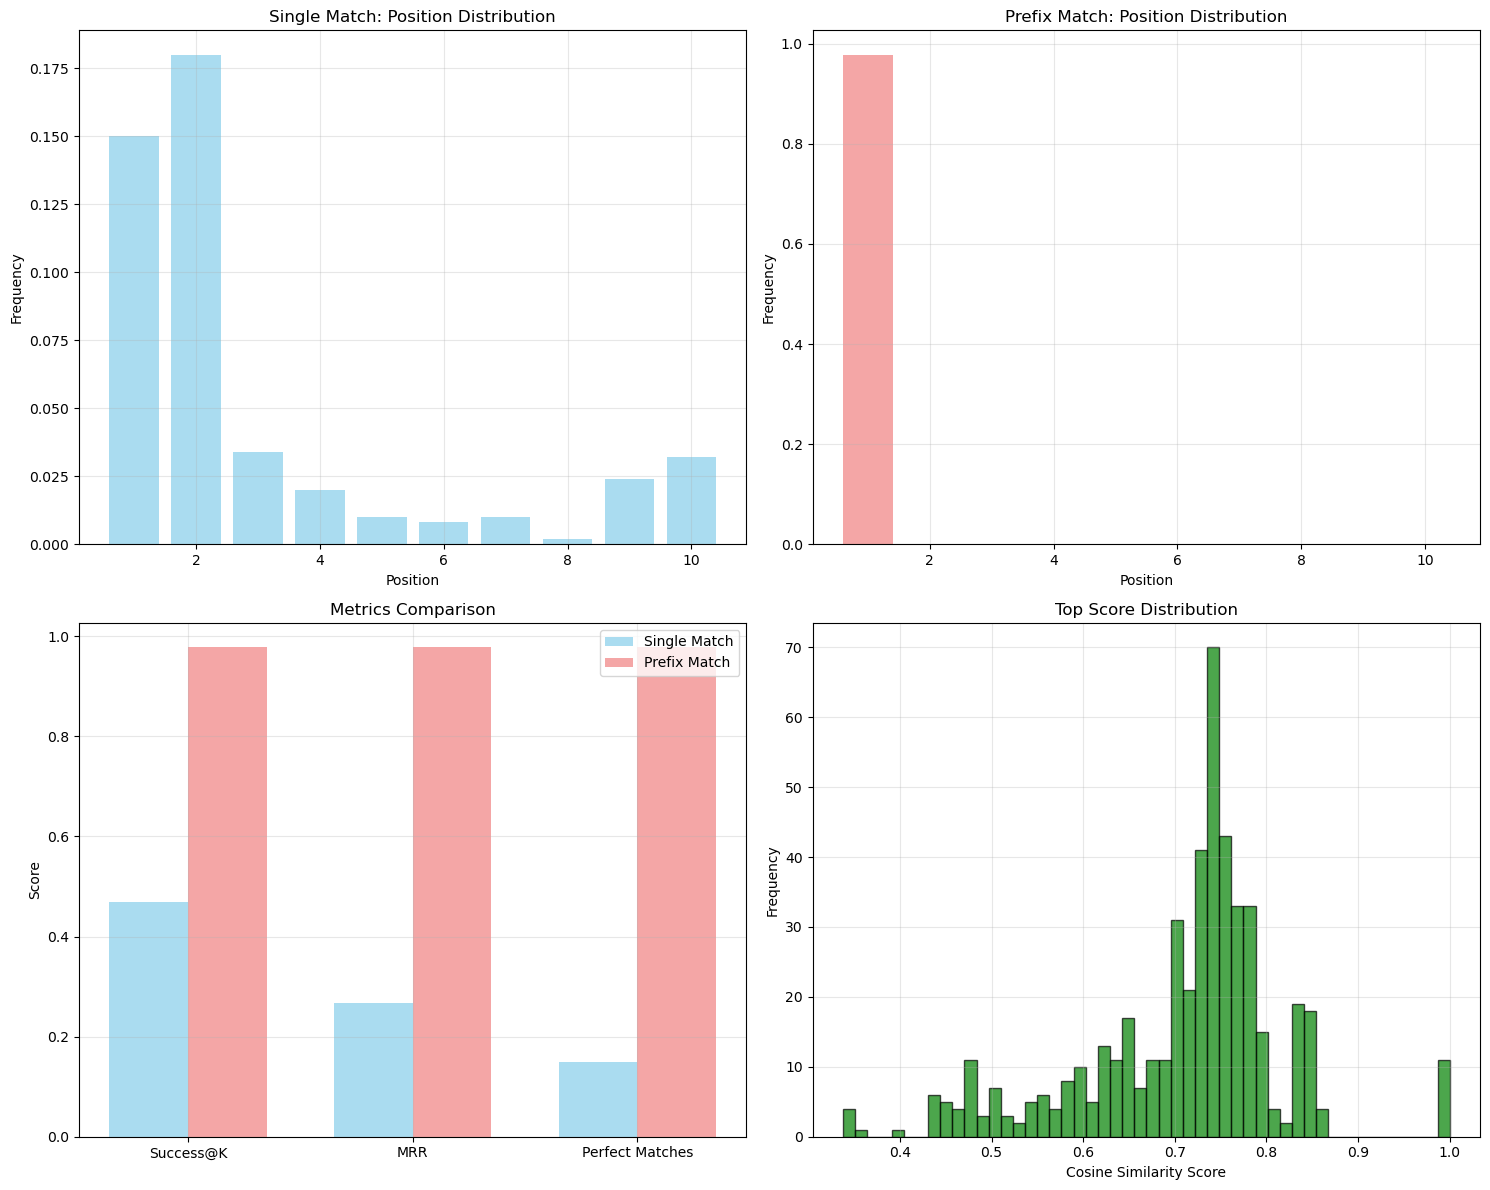

💾 Evaluation results saved to: /work/sandbox/splade/evaluation_results/OEB_baseline_eval_filtered_5000_500.pkl
📄 Summary saved to: /work/sandbox/splade/evaluation_results/OEB_baseline_eval_filtered_5000_500.json

✅ Baseline evaluation complete!
💾 Memory Status final cleanup:
   RSS: 2.38 GB
   VMS: 74.19 GB
   Percent: 7.6%


In [10]:
results = quick_evaluation(sample_size=500, max_features=5000)